In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score

In [ ]:

# 1. ה-ID שחולץ מהקישור שלך
FILE_ID = '1sUuK6X6bi2cWoYHYDrQVruUT_vOC36fJ'

# 2. יצירת הכתובת להורדה ישירה
direct_url = f'https://drive.google.com/uc?export=download&id={FILE_ID}'

# 3. קריאת הקובץ (מחליף את ה-Mount ואת הנתיב המקומי)
df = pd.read_csv(direct_url)

# הצגת מידע ראשוני לוודא שהכל נטען
print(f"✅ הקובץ נטען בהצלחה!")
print(f"צורת הדאטה: {df.shape}")
print(df.head())

✅ הקובץ נטען בהצלחה!
צורת הדאטה: (93388, 54)
                        name_1  \
0  Casemiro Nascimento Martins   
1          Kazuhiro Kusayanagi   
2               Naoki Sakurada   
3            Kazuhiro Sakamoto   
4              Mitsuo Fujikura   

                                               url_1   id_1        date  \
0  https://www.sherdog.com/fighter/Casemiro-Nasci...   1234  1984-11-30   
1  https://www.sherdog.com/fighter/Kazuhiro-Kusay...    471  1989-10-19   
2  https://www.sherdog.com/fighter/Naoki-Sakurada...   1178  1989-10-19   
3  https://www.sherdog.com/fighter/Kazuhiro-Sakam...   1181  1989-10-19   
4                     /fighter/Mitsuo-Fujikura-10600  10600  1989-10-19   

   age_1 birth_date_1          association_1    style_1 nationality_1  \
0     43          NaN                    NaN  Vale Tudo        Brazil   
1     22          NaN            K'z Factory     Shooto         Japan   
2     23   1966-05-12                Gutsman        NaN         Japan   
3     2

In [ ]:
from collections import defaultdict

# 1. Tracker for current streaks only
# Positive values = Win Streak, Negative values = Loss Streak
fighter_streaks = defaultdict(lambda: 0)

f1_streak, f2_streak = [], []

# 2. Process fights chronologically
for idx, row in df.iterrows():
    fid1, fid2 = f"{row['name_1']}_{row['id_1']}", f"{row['name_2']}_{row['id_2']}"

    # Capture state BEFORE the fight happens
    f1_streak.append(fighter_streaks[fid1])
    f2_streak.append(fighter_streaks[fid2])

    # 3. Update Streaks after the fight
    res, m = row['result'], str(row['method'])

    # Only update for decisive results
    if m not in ['NC', 'Draw', 'Majority Draw', 'ND', 'No Contest', 'Injury']:
        winner = fid1 if res == 'fighter1' else fid2
        loser = fid2 if res == 'fighter1' else fid1

        # Update Winner: Increment if already on win streak, else start at 1
        if fighter_streaks[winner] > 0:
            fighter_streaks[winner] += 1
        else:
            fighter_streaks[winner] = 1

        # Update Loser: Decrement if already on loss streak, else start at -1
        if fighter_streaks[loser] < 0:
            fighter_streaks[loser] -= 1
        else:
            fighter_streaks[loser] = -1

# 4. Assign to DataFrame
df['streak_1'] = f1_streak
df['streak_2'] = f2_streak

In [ ]:
from collections import defaultdict

# 1. Trackers for win history
fighter_total_win_time = defaultdict(float)
fighter_win_count = defaultdict(int)

avg_win_time_1, avg_win_time_2 = [], []

# 2. Process fights chronologically
for idx, row in df.iterrows():
    fid1 = f"{row['name_1']}_{row['id_1']}"
    fid2 = f"{row['name_2']}_{row['id_2']}"

    # Capture BEFORE state (average win time prior to this fight)
    # This prevents data leakage
    avg1 = fighter_total_win_time[fid1] / fighter_win_count[fid1] if fighter_win_count[fid1] > 0 else 0
    avg2 = fighter_total_win_time[fid2] / fighter_win_count[fid2] if fighter_win_count[fid2] > 0 else 0

    avg_win_time_1.append(avg1)
    avg_win_time_2.append(avg2)

    # 3. Calculate absolute elapsed time for this specific fight
    # Standard MMA round is 300 seconds (5 mins)
    total_elapsed_seconds = ((row['round'] - 1) * 300) + row['time']

    # 4. Update ONLY the winner's stats
    # (Because "average time to win" only counts their successful finishes/decisions)
    if row['result'] == 'fighter1':
        fighter_total_win_time[fid1] += total_elapsed_seconds
        fighter_win_count[fid1] += 1
    elif row['result'] == 'fighter2':
        fighter_total_win_time[fid2] += total_elapsed_seconds
        fighter_win_count[fid2] += 1

# 5. Add to DataFrame
df['avg_win_time_1'] = avg_win_time_1
df['avg_win_time_2'] = avg_win_time_2

In [ ]:
from collections import defaultdict

# 1. Trackers
fighter_total_rounds = defaultdict(float)
fighter_fight_count = defaultdict(int)

avg_round_1, avg_round_2 = [], []

# 2. Process fights chronologically
for idx, row in df.iterrows():
    fid1 = f"{row['name_1']}_{row['id_1']}"
    fid2 = f"{row['name_2']}_{row['id_2']}"

    # Capture BEFORE state (average rounds per fight prior to this one)
    ar1 = fighter_total_rounds[fid1] / fighter_fight_count[fid1] if fighter_fight_count[fid1] > 0 else 0
    ar2 = fighter_total_rounds[fid2] / fighter_fight_count[fid2] if fighter_fight_count[fid2] > 0 else 0

    avg_round_1.append(ar1)
    avg_round_2.append(ar2)

    # 3. Update stats AFTER the fight
    # We use the round the fight ended in as the 'rounds lasted' for that fight
    current_fight_round = row['round']

    # Update Fighter 1
    fighter_total_rounds[fid1] += current_fight_round
    fighter_fight_count[fid1] += 1

    # Update Fighter 2
    fighter_total_rounds[fid2] += current_fight_round
    fighter_fight_count[fid2] += 1

# 4. Assign to DataFrame
df['avg_round_1'] = avg_round_1
df['avg_round_2'] = avg_round_2

In [ ]:
from collections import defaultdict

# 1. Tracker for win types (internal only)
fighter_stats = defaultdict(lambda: {'ko': 0, 'sub': 0, 'unanimous': 0, 'split': 0})

# Temporary lists to store the common method strings
f1_common_methods = []
f2_common_methods = []

# Helper function to determine the string internally during the loop
def determine_common(stats):
    max_v = max(stats.values())
    if max_v == 0:
        return "None"
    winners = [k for k, v in stats.items() if v == max_v]
    if len(winners) > 1:
        return "Mixed"
    return winners[0]

# 2. Process fights chronologically
for idx, row in df.iterrows():
    fid1, fid2 = f"{row['name_1']}_{row['id_1']}", f"{row['name_2']}_{row['id_2']}"

    # 3. Capture Common Method BEFORE the fight updates (No Leakage)
    f1_common_methods.append(determine_common(fighter_stats[fid1]))
    f2_common_methods.append(determine_common(fighter_stats[fid2]))

    # 4. Update internal counts for future rows
    res, m = row['result'], str(row['method'])
    non_decisive = ['NC', 'Draw', 'Majority Draw', 'ND', 'No Contest', 'Injury']

    if m not in non_decisive:
        winner = fid1 if res == 'fighter1' else fid2

        # Cleaned up the KO/TKO logic check
        if m in ['KO', 'TKO', 'KO/TKO']:
            fighter_stats[winner]['ko'] += 1
        elif m == 'Submission':
            fighter_stats[winner]['sub'] += 1
        elif 'Unanimous Decision' in m:
            fighter_stats[winner]['unanimous'] += 1
        elif 'Split Decision' in m or 'Majority Decision' in m:
            fighter_stats[winner]['split'] += 1

# 5. Assign ONLY the common method strings to the DataFrame
df['common_method_1'] = f1_common_methods
df['common_method_2'] = f2_common_methods

In [ ]:
# 1. Get the frequency of every fighter ID in the entire dataset
all_fighters = pd.concat([df['id_1'], df['id_2']])
fight_counts = all_fighters.value_counts()

# 2. Map those counts back to the fighter_1 and fighter_2 columns
df['f1_count'] = df['id_1'].map(fight_counts)
df['f2_count'] = df['id_2'].map(fight_counts)

# 3. Filter: Keep only fights where BOTH have 5 or more appearances
df_filtered = df[(df['f1_count'] >= 2) & (df['f2_count'] >= 2)].copy()

# Optional: Clean up the helper columns
df_filtered = df_filtered.drop(columns=['f1_count', 'f2_count'])

print(f"Original fights: {len(df)}")
print(f"Fights remaining after filtering: {len(df_filtered)}")

Original fights: 93388
Fights remaining after filtering: 73778


In [ ]:
df=df[df['class']!='Super Heavyweight']

In [ ]:
from google.colab import auth
import gspread
from google.auth import compute_engine
from google.auth import default

# אימות המשתמש
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

# פתיחת הגיליון לפי השם שלו (תוודא שהשם מדויק)
sheet = gc.open('גיליון ניסיונות ').sheet1

In [ ]:
def log_experiment_to_sheets(data_list):
    # כאן אנחנו משתמשים ב-row_count כדי למצוא את השורה הבאה
    # בלי להשתמש ב-get_all_records שגורם לשגיאת הכפילויות
    all_values = sheet.col_values(1) # קורא רק את העמודה הראשונה כדי לדעת כמה שורות יש
    next_index = len(all_values)

    experiment_name = f"Experiment {next_index}"
    data_to_save = [experiment_name] + data_list

    sheet.append_row(data_to_save)
    print(f"נשמר בהצלחה בתור: {experiment_name}")

In [ ]:
# 1. יצירת עותק והגדרת המדגם הקבוע
df_swap = df.copy()
rows_to_swap = df_swap.sample(frac=0.5, random_state=30).index

# 2. הגדרת עמודות להחלפה
f1_cols = ['name_1', 'url_1', 'id_1', 'age_1', 'birth_date_1', 'association_1',
           'style_1', 'nationality_1', 'birthplace_1', 'wins_total_1', 'wins_ko_1',
           'wins_sub_1', 'wins_dec_1', 'losses_total_1', 'losses_ko_1',
           'losses_sub_1', 'losses_dec_1', 'weight_lbs_1', 'weight_kg_1', 'height_cm_1']

f2_cols = ['name_2', 'url_2', 'id_2', 'age_2', 'birth_date_2', 'association_2',
           'style_2', 'nationality_2', 'birthplace_2', 'wins_total_2', 'wins_ko_2',
           'wins_sub_2', 'wins_dec_2', 'losses_total_2', 'losses_ko_2',
           'losses_sub_2', 'losses_dec_2', 'weight_lbs_2', 'weight_kg_2', 'height_cm_2']

# 3. ביצוע ההחלפה (Swap)
temp_f1 = df_swap.loc[rows_to_swap, f1_cols].values
temp_f2 = df_swap.loc[rows_to_swap, f2_cols].values

df_swap.loc[rows_to_swap, f1_cols] = temp_f2
df_swap.loc[rows_to_swap, f2_cols] = temp_f1

# 4. עדכון ה-Result עבור השורות שהוחלפו
# הופך 'fighter1' ל-'fighter2' ולהיפך
map_results = {'fighter1': 'fighter2', 'fighter2': 'fighter1'}
df_swap.loc[rows_to_swap, 'result'] = df_swap.loc[rows_to_swap, 'result'].replace(map_results)

In [ ]:
df=df_swap.copy()

In [ ]:
df.drop(['name_1', 'url_1', 'id_1', 'name_2', 'url_2', 'id_2', 'association_1', 'association_2', 'event_url', 'event_id', 'event_name', 'explanation', 'referee', 'class', 'nationality_1', 'style_1', 'weight_lbs_1', 'nationality_2', 'style_2', 'weight_lbs_2', 'birth_date_1', 'birth_date_2', 'birthplace_1', 'birthplace_2', 'debut_year_1', 'debut_year_2', 'organization', 'date'], axis=1, inplace=True)

In [ ]:
df_2step_classification=df.copy()

In [ ]:
df_2step_classification.columns

Index(['age_1', 'wins_total_1', 'wins_ko_1', 'wins_sub_1', 'wins_dec_1',
       'losses_total_1', 'losses_ko_1', 'losses_sub_1', 'losses_dec_1',
       'weight_kg_1', 'height_cm_1', 'age_2', 'wins_total_2', 'wins_ko_2',
       'wins_sub_2', 'wins_dec_2', 'losses_total_2', 'losses_ko_2',
       'losses_sub_2', 'losses_dec_2', 'weight_kg_2', 'height_cm_2', 'result',
       'method', 'round', 'time', 'streak_1', 'streak_2', 'avg_win_time_1',
       'avg_win_time_2', 'avg_round_1', 'avg_round_2', 'common_method_1',
       'common_method_2', 'f1_count', 'f2_count'],
      dtype='object')

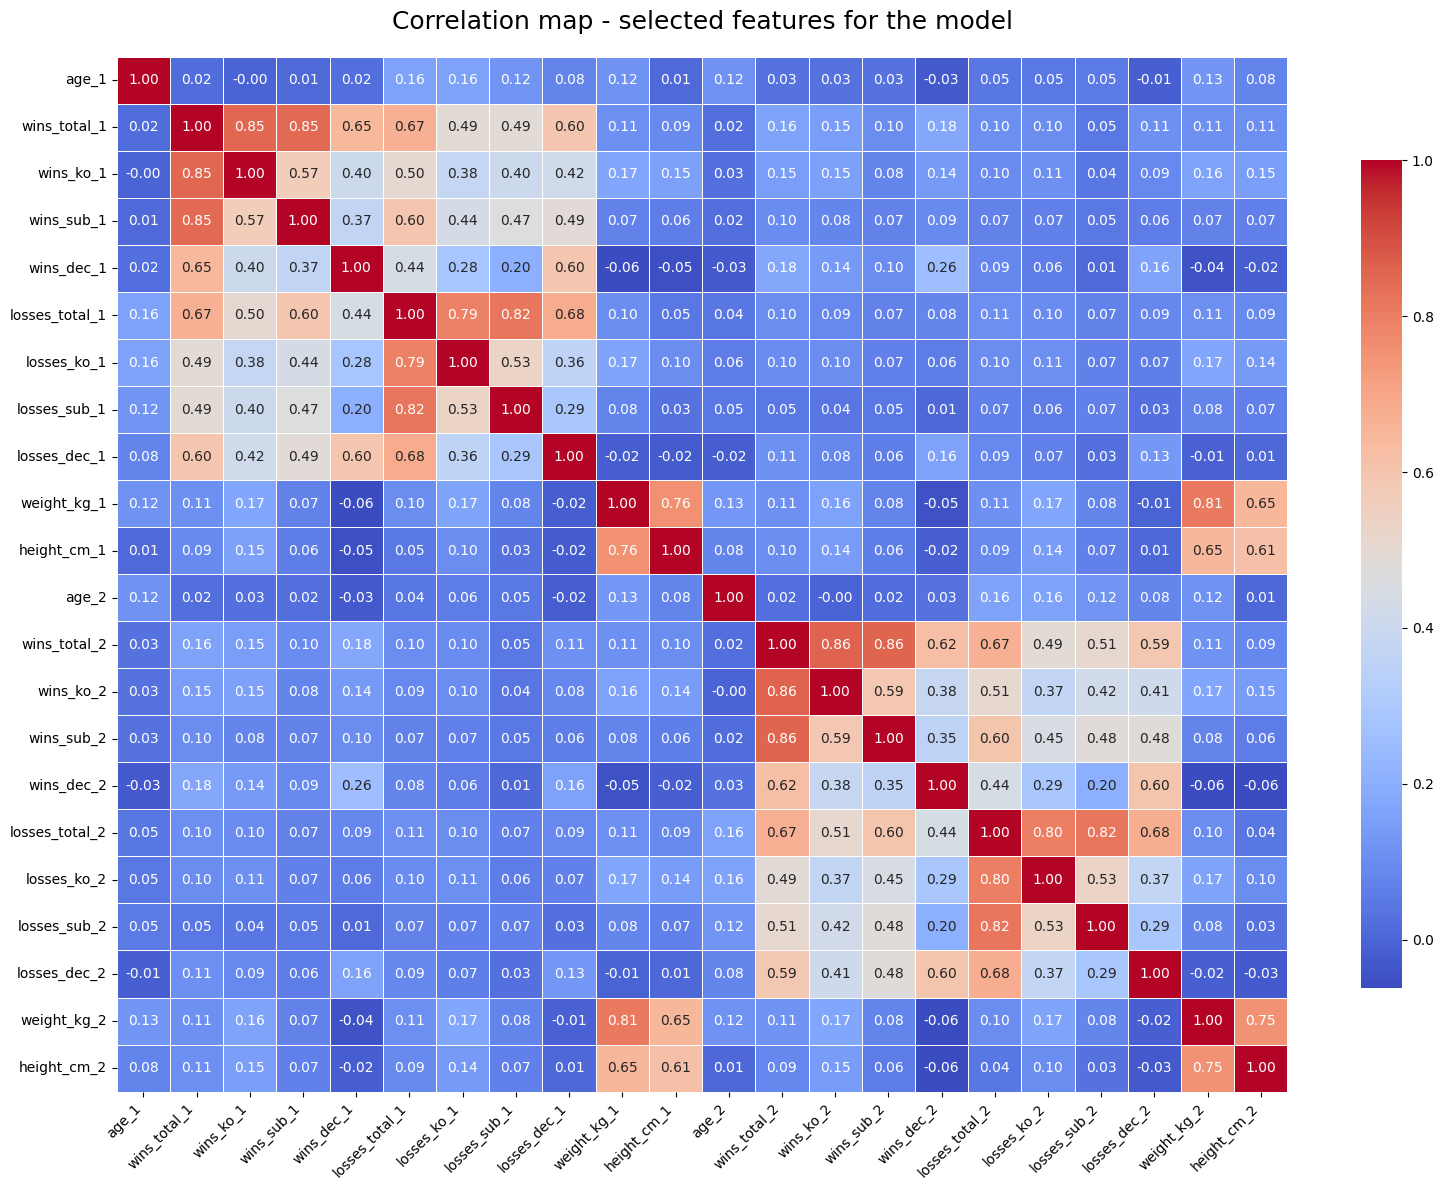

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. רשימת הפיצ'רים שביקשת (הנומריים)
selected_features = [
    'age_1', 'wins_total_1', 'wins_ko_1', 'wins_sub_1', 'wins_dec_1',
    'losses_total_1', 'losses_ko_1', 'losses_sub_1', 'losses_dec_1',
    'weight_kg_1', 'height_cm_1', 'age_2', 'wins_total_2', 'wins_ko_2',
    'wins_sub_2', 'wins_dec_2', 'losses_total_2', 'losses_ko_2',
    'losses_sub_2', 'losses_dec_2', 'weight_kg_2', 'height_cm_2'
]

# 2. חישוב מטריצת הקורלציה רק עבור הפיצ'רים האלו
# אנחנו מוודאים שהם קיימים ב-df ושהם נומריים
correlation_matrix = df[selected_features].corr()

# 3. יצירת ה-Heatmap
plt.figure(figsize=(16, 12)) # גודל גדול כדי שהכל יהיה קריא למצגת
sns.heatmap(correlation_matrix,
            annot=True,          # מציג את המספרים בתוך הריבועים
            cmap='coolwarm',     # צבעים: אדום לקורלציה חיובית, כחול לשלילית
            fmt=".2f",           # עיגול ל-2 ספרות אחרי הנקודה
            linewidths=0.5,      # רווח קטן בין הריבועים
            cbar_kws={"shrink": .8})

plt.title("Correlation map - selected features for the model", fontsize=18, pad=20)
plt.xticks(rotation=45, ha='right') # סיבוב שמות הפיצ'רים למטה
plt.yticks(rotation=0)
plt.tight_layout()

# 4. שמירת התמונה באיכות גבוהה למצגת

In [ ]:
# Define the explicit mapping dictionary
outcome_map = {
    'fighter1': 1,
    'fighter2': 2
}

# 1. Select your target column.
target_column = df_2step_classification['result']

# 2. Apply the mapping using the .map() method
df_2step_classification['result'] = target_column.map(outcome_map)

In [ ]:
df_2step_classification=df_2step_classification[df_2step_classification['method']!='Split Decision']

In [ ]:
# Define the explicit mapping dictionary
# The order is arbitrary, starting from 0.
outcome_map_v2 = {
    'KO/TKO': 2,
    'Submission': 3,
    'Unanimous Decision': 1
}

# Assuming your target column is named 'result' in your DataFrame df_2step_classification
target_column = df_2step_classification['method']

# 1. Apply the mapping using the .map() method
# This replaces the text values with the assigned numbers (0 through 4)
df_2step_classification['method_encoded'] = target_column.map(outcome_map_v2)

# 2. Display a sample check
print("--- Sample Check: Original vs. Encoded ---")
print(df_2step_classification[['method', 'method_encoded']].head())

--- Sample Check: Original vs. Encoded ---
               method  method_encoded
0          Submission               3
1              KO/TKO               2
2  Unanimous Decision               1
3          Submission               3
4          Submission               3


In [ ]:
df_2step_classification['method']=df_2step_classification['method_encoded']

In [ ]:
df_2step_classification['method']=df_2step_classification['method_encoded']

In [ ]:
df_2step_classification['height_diff'] = df_2step_classification['height_cm_1'] - df_2step_classification['height_cm_2']
df_2step_classification['weight_diff'] = df_2step_classification['weight_kg_1'] - df_2step_classification['weight_kg_2']
df_2step_classification['age_diff'] = df_2step_classification['age_1'] - df_2step_classification['age_2']

In [ ]:
df_2step_classification['total_fights_1'] = df_2step_classification['wins_total_1'] + df_2step_classification['losses_total_1']
df_2step_classification['total_fights_2'] = df_2step_classification['wins_total_2'] + df_2step_classification['losses_total_2']

In [ ]:
df_model = df_2step_classification.copy()

# 2. List of old columns to delete at the end
old_features = [
    'wins_ko_1', 'wins_sub_1', 'wins_dec_1', 'losses_ko_1', 'losses_sub_1', 'losses_dec_1',
    'wins_ko_2', 'wins_sub_2', 'wins_dec_2', 'losses_ko_2', 'losses_sub_2', 'losses_dec_2'
]

# 3. Calculate percentages for Fighter 1
df_model['wins_ko_percent_1'] = df_model['wins_ko_1'] / df_model['wins_total_1'].replace(0, 1)
df_model['wins_sub_percent_1'] = df_model['wins_sub_1'] / df_model['wins_total_1'].replace(0, 1)
df_model['wins_dec_percent_1'] = df_model['wins_dec_1'] / df_model['wins_total_1'].replace(0, 1)

df_model['losses_ko_percent_1'] = df_model['losses_ko_1'] / df_model['losses_total_1'].replace(0, 1)
df_model['losses_sub_percent_1'] = df_model['losses_sub_1'] / df_model['losses_total_1'].replace(0, 1)
df_model['losses_dec_percent_1'] = df_model['losses_dec_1'] / df_model['losses_total_1'].replace(0, 1)

# 4. Calculate percentages for Fighter 2
df_model['wins_ko_percent_2'] = df_model['wins_ko_2'] / df_model['wins_total_2'].replace(0, 1)
df_model['wins_sub_percent_2'] = df_model['wins_sub_2'] / df_model['wins_total_2'].replace(0, 1)
df_model['wins_dec_percent_2'] = df_model['wins_dec_2'] / df_model['wins_total_2'].replace(0, 1)

df_model['losses_ko_percent_2'] = df_model['losses_ko_2'] / df_model['losses_total_2'].replace(0, 1)
df_model['losses_sub_percent_2'] = df_model['losses_sub_2'] / df_model['losses_total_2'].replace(0, 1)
df_model['losses_dec_percent_2'] = df_model['losses_dec_2'] / df_model['losses_total_2'].replace(0, 1)

# 5. Delete old columns (optional - based on your comment in the image)
# df_model = df_model.drop(columns=old_features)

# 6. Final cleaning - fill NaNs with 0
df_model = df_model.fillna(0)

In [ ]:
df_2step_classification=df_model.copy()

In [ ]:
# 1. Define the mapping based on your requirements
method_map = {
    'None': 0,
    'unanimous': 1,
    'ko': 2,        # This matches the 'ko' string from our previous logic
    'sub': 3,
    'split': 4,
    'Mixed': 5
}

# 2. Apply the mapping to both columns
# We use .fillna(0) just in case there are any unexpected empty values
df_2step_classification['common_method_1'] = df_2step_classification['common_method_1'].map(method_map).fillna(0).astype(int)
df_2step_classification['common_method_2'] = df_2step_classification['common_method_2'].map(method_map).fillna(0).astype(int)

# 3. Verify the transformation
df_2step_classification[['common_method_1', 'common_method_2']]

,common_method_1,common_method_2
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
...,...,...
93383,2,2
93384,2,2
93385,1,1
93386,3,0


In [ ]:
df_2step_classification.columns

Index(['age_1', 'wins_total_1', 'wins_ko_1', 'wins_sub_1', 'wins_dec_1',
       'losses_total_1', 'losses_ko_1', 'losses_sub_1', 'losses_dec_1',
       'weight_kg_1', 'height_cm_1', 'age_2', 'wins_total_2', 'wins_ko_2',
       'wins_sub_2', 'wins_dec_2', 'losses_total_2', 'losses_ko_2',
       'losses_sub_2', 'losses_dec_2', 'weight_kg_2', 'height_cm_2', 'result',
       'method', 'round', 'time', 'streak_1', 'streak_2', 'avg_win_time_1',
       'avg_win_time_2', 'avg_round_1', 'avg_round_2', 'common_method_1',
       'common_method_2', 'f1_count', 'f2_count', 'method_encoded',
       'height_diff', 'weight_diff', 'age_diff', 'total_fights_1',
       'total_fights_2', 'wins_ko_percent_1', 'wins_sub_percent_1',
       'wins_dec_percent_1', 'losses_ko_percent_1', 'losses_sub_percent_1',
       'losses_dec_percent_1', 'wins_ko_percent_2', 'wins_sub_percent_2',
       'wins_dec_percent_2', 'losses_ko_percent_2', 'losses_sub_percent_2',
       'losses_dec_percent_2'],
      dtype='object')

In [ ]:
df_2step_classification['common_method_1']

,common_method_1
0,0
1,0
2,0
3,0
4,0
...,...
93383,2
93384,2
93385,1
93386,3


In [ ]:
df_2step_classification.columns

Index(['age_1', 'wins_total_1', 'wins_ko_1', 'wins_sub_1', 'wins_dec_1',
       'losses_total_1', 'losses_ko_1', 'losses_sub_1', 'losses_dec_1',
       'weight_kg_1', 'height_cm_1', 'age_2', 'wins_total_2', 'wins_ko_2',
       'wins_sub_2', 'wins_dec_2', 'losses_total_2', 'losses_ko_2',
       'losses_sub_2', 'losses_dec_2', 'weight_kg_2', 'height_cm_2', 'result',
       'method', 'round', 'time', 'streak_1', 'streak_2', 'avg_win_time_1',
       'avg_win_time_2', 'avg_round_1', 'avg_round_2', 'common_method_1',
       'common_method_2', 'f1_count', 'f2_count', 'method_encoded',
       'height_diff', 'weight_diff', 'age_diff', 'total_fights_1',
       'total_fights_2', 'wins_ko_percent_1', 'wins_sub_percent_1',
       'wins_dec_percent_1', 'losses_ko_percent_1', 'losses_sub_percent_1',
       'losses_dec_percent_1', 'wins_ko_percent_2', 'wins_sub_percent_2',
       'wins_dec_percent_2', 'losses_ko_percent_2', 'losses_sub_percent_2',
       'losses_dec_percent_2'],
      dtype='object')

In [ ]:
df_2step_classification['total_fights_1']

,total_fights_1
0,2
1,0
2,0
3,1
4,0
...,...
93383,25
93384,18
93385,15
93386,17


In [ ]:
def add_mma_features(df):
    df = df.copy()
    for i in ['1', '2']:
        # Protect against division by zero
        total_fights = df[f'total_fights_{i}'].replace(0, 1)
        # Win Rate
        wr = df[f'wins_total_{i}'] / total_fights
        # Finish Rate (KO + Sub)
        fr = (df[f'wins_ko_{i}'] + df[f'wins_sub_{i}']) / total_fights
        # Quality Score: Weighted 60% Wins, 40% Finishes
        df[f'quality_score_{i}'] = (wr * 0.6 + fr * 0.4)
    return df
df_processed = add_mma_features(df_2step_classification)

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# --- 1. FEATURE ENGINEERING (From Script 1) ---

df_processed = add_mma_features(df_2step_classification)
# Adjusting result if it's 1-indexed (Common in your second script)
if df_processed['result'].min() == 1:
    df_processed['result'] = df_processed['result'] - 1

# --- 2. THE 60/20/20 SPLIT (From Script 2) ---
# This ensures you never "leak" test data into your training process
df_train_val, df_test = train_test_split(
    df_processed, test_size=0.20, random_state=42, stratify=df_processed['result']
)
df_train, df_val = train_test_split(
    df_train_val, test_size=0.25, random_state=42, stratify=df_train_val['result']
)

# --- 3. FEATURE SELECTION LOGIC ---
# Define what to EXCLUDE to avoid leakage or noise
old_raw_features = ['wins_ko_1', 'wins_sub_1', 'wins_dec_1', 'losses_ko_1', 'losses_sub_1', 'losses_dec_1',
                    'wins_ko_2', 'wins_sub_2', 'wins_dec_2', 'losses_ko_2', 'losses_sub_2', 'losses_dec_2']

remove_from_step1 = ['result', 'method', 'round', 'time','method_encoded','f1_count','f2_count'] + old_raw_features
X1_cols = [col for col in df_processed.columns if col not in remove_from_step1]

# --- 4. STEP 1: WINNER ENSEMBLE ---
vc1 = VotingClassifier(
    estimators=[
        ('xgb', xgb.XGBClassifier(n_estimators=250, learning_rate=0.05, max_depth=5, random_state=42)),
        ('lgbm', lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, num_leaves=30, random_state=42, verbose=-1))
    ],
    voting='soft'
)

print("Training Step 1: Winner Model...")
vc1.fit(df_train[X1_cols], df_train['result'])

# --- 5. INJECT META-FEATURES (The Bridge) ---
for target_df in [df_train, df_val, df_test]:
    target_df['win_prob'] = vc1.predict_proba(target_df[X1_cols])[:, 1]
    target_df['win_pred'] = vc1.predict(target_df[X1_cols])

# --- 6. STEP 2: METHOD ENSEMBLE ---
# We keep the winner's probability and prediction to help guess the METHOD
X2_cols = X1_cols + ['win_prob']
val_acc = accuracy_score(df_val['result'], vc1.predict(df_val[X1_cols]))
test_acc = accuracy_score(df_test['result'], vc1.predict(df_test[X1_cols]))
print(f"Winner Accuracy -> Val: {val_acc:.4f} | Test: {test_acc:.4f}")
vc2 = VotingClassifier(
    estimators=[
        ('xgb', xgb.XGBClassifier(n_estimators=250, max_depth=4, learning_rate=0.05, random_state=42)),
        ('lgbm', lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, num_leaves=20, random_state=42, verbose=-1))
    ],
    voting='soft'
)

print("Training Step 2: Method Model...")
vc2.fit(df_train[X2_cols], df_train['method'])

# --- 7. EVALUATION ---
val_f1 = f1_score(df_val['method'], vc2.predict(df_val[X2_cols]), average='macro')
method_f1 = f1_score(df_test['method'], vc2.predict(df_test[X2_cols]),average='macro')
print(f"Method f1 (macro) -> Val: {val_f1:.4f} | Test: {method_f1:.4f}")
print("="*30)

Training Step 1: Winner Model...
Winner Accuracy -> Val: 0.7371 | Test: 0.7352
Training Step 2: Method Model...
Method f1 (macro) -> Val: 0.4816 | Test: 0.4891


In [ ]:
# --- 8. TRAIN SET EVALUATION ---

# חיזויים עבור שלב 1 (Winner) על סט האימון
train_win_preds = vc1.predict(df_train[X1_cols])
train_win_acc = accuracy_score(df_train['result'], train_win_preds)

# חיזויים עבור שלב 2 (Method) על סט האימון
train_method_preds = vc2.predict(df_train[X2_cols])
train_method_f1 = f1_score(df_train['method'], train_method_preds, average='macro')

print("\n" + " Train Set Performance ".center(30, "="))
print(f"Winner Accuracy (Train): {train_win_acc:.4f}")
print(f"Method F1 Macro (Train): {train_method_f1:.4f}")
print("="*30)

# השוואה מהירה כדי לראות אם יש Overfitting
print(f"\nGap (Winner): {train_win_acc - test_acc:.4f}")
print(f"Gap (Method): {train_method_f1 - method_f1:.4f}")


=== Train Set Performance ====
Winner Accuracy (Train): 0.7654
Method F1 Macro (Train): 0.5237

Gap (Winner): 0.0303
Gap (Method): 0.0346


In [ ]:
import matplotlib.pyplot as plt

# --- פונקציה להצגת גרף הלמידה ---
def plot_learning_curves(model_history, title, metric='logloss'):
    plt.figure(figsize=(10, 5))
    # חילוץ הנתונים מההיסטוריה
    results = model_history
    epochs = len(results['validation_0'][metric])
    x_axis = range(0, epochs)

    plt.plot(x_axis, results['validation_0'][metric], label='Train', linewidth=2)
    plt.plot(x_axis, results['validation_1'][metric], label='Val', linewidth=2)

    plt.legend()
    plt.ylabel(metric.capitalize())
    plt.xlabel('Iterations (Number of Trees)')
    plt.title(title, fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

# --- STEP 1: TRACKING WINNER MODEL IMPROVEMENT ---
# --- STEP 1: WINNER MODEL WITH EARLY STOPPING ---
from sklearn.preprocessing import LabelEncoder

# 1. יצירת מקודד ואימון שלו על כל ערכי ה-method האפשריים
le = LabelEncoder()
# אימון על כל הנתונים כדי לוודא שכל שיטה מקבלת מספר
le.fit(df_processed['method'])

# 2. עדכון הנתונים ב-DataFrames השונים
df_train['method_enc'] = le.transform(df_train['method'])
df_val['method_enc'] = le.transform(df_val['method'])
df_test['method_enc'] = le.transform(df_test['method'])

print(f"Mapping labels: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# --- STEP 2: METHOD MODEL WITH EARLY STOPPING ---
print("🎯 Training Step 2: Optimal Method Model...")

vc2_optimal = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric="mlogloss",
    early_stopping_rounds=25
)

# שים לב שאנחנו משתמשים ב-'method_enc' כאן
vc2_optimal.fit(
    df_train[X2_cols], df_train['method_enc'],
    eval_set=[(df_val[X2_cols], df_val['method_enc'])],
    verbose=False
)

# --- EVALUATION ---
# חיזוי (התוצאה תהיה 0, 1, 2)
y2_pred_enc = vc2_optimal.predict(df_test[X2_cols])

# חישוב F1 (נשתמש ב-method_enc של הטסט להשוואה)
final_method_f1 = f1_score(df_test['method_enc'], y2_pred_enc, average='macro')

print("\n" + "Summary".center(30, "="))
print(f"Method F1-Score: {final_method_f1:.4f} (Stopped at {vc2_optimal.best_iteration})")

Mapping labels: {np.int64(1): np.int64(0), np.int64(2): np.int64(1), np.int64(3): np.int64(2)}
🎯 Training Step 2: Optimal Method Model...

===========Summary============
Method F1-Score: 0.4885 (Stopped at 216)


/tmp/ipykernel_1426/1891354804.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')


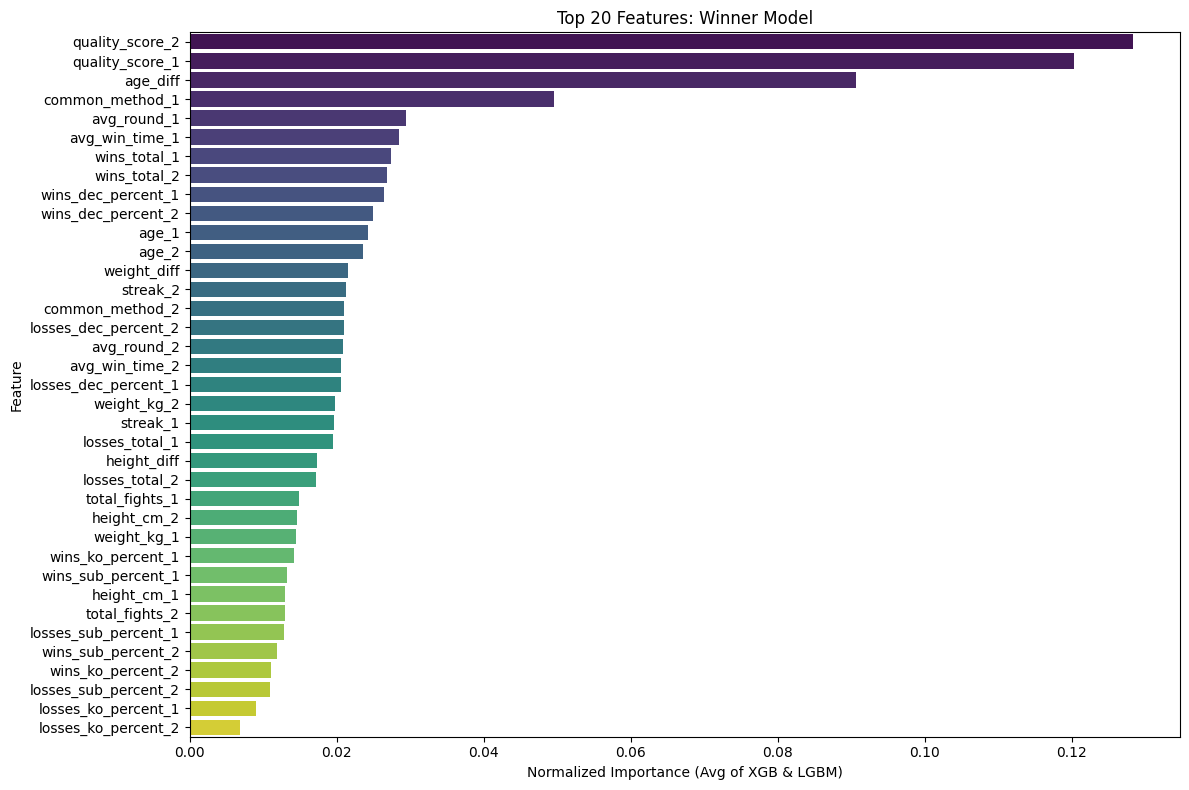

/tmp/ipykernel_1426/1891354804.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')


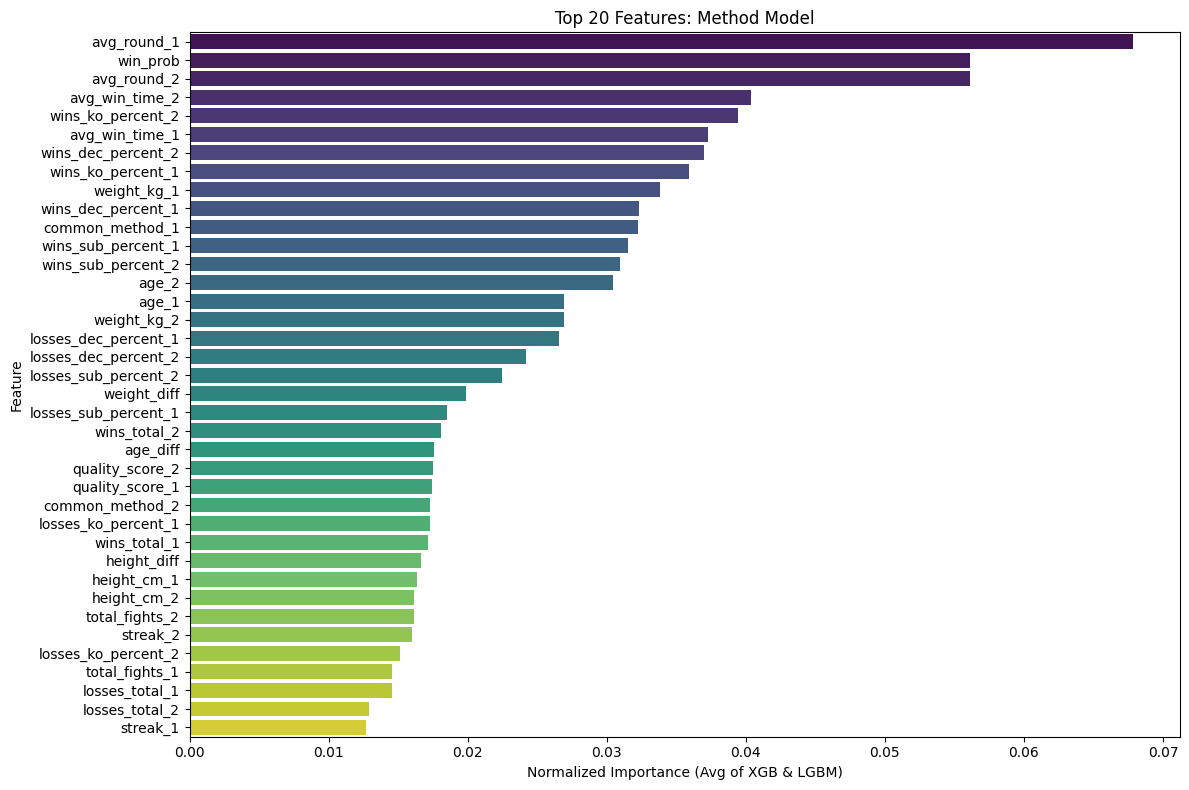

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_voting_importance(voting_model, feature_names, title="Feature Importance"):
    # 1. Extract importance from the sub-models
    # XGBoost importance
    xgb_importance = voting_model.named_estimators_['xgb'].feature_importances_
    # LightGBM importance (scaled to match XGBoost's range)
    lgbm_importance = voting_model.named_estimators_['lgbm'].feature_importances_
    lgbm_importance = lgbm_importance / lgbm_importance.sum()
    xgb_importance = xgb_importance / xgb_importance.sum()

    # 2. Average them
    avg_importance = (xgb_importance + lgbm_importance) / 2

    # 3. Create DataFrame for plotting
    feat_imp_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': avg_importance
    }).sort_values(by='Importance', ascending=False)

    # 4. Plot
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
    plt.title(f'Top 20 Features: {title}')
    plt.xlabel('Normalized Importance (Avg of XGB & LGBM)')
    plt.tight_layout()
    plt.show()

# Run for Step 1 (Winner)
plot_voting_importance(vc1, X1_cols, title="Winner Model")

# Run for Step 2 (Method) - Note the different columns here
plot_voting_importance(vc2, X2_cols, title="Method Model")

In [ ]:
# --- 8. DETAILED F1 SCORE EVALUATION ---

# 1. Calculate Winner Model F1 (Step 1)
y1_true = df_test['result']
y1_pred = vc1.predict(df_test[X1_cols])
winner_f1 = f1_score(y1_true, y1_pred, average='macro')

# 2. Calculate Method Model F1 (Step 2)
y2_true = df_test['method']
y2_pred = vc2.predict(df_test[X2_cols])
method_f1_score = f1_score(y2_true, y2_pred, average='macro')

print("\n" + "="*40)
print("FINAL MODEL PERFORMANCE (TEST SET)")
print("-"*40)
print(f"STEP 1: Winner Prediction F1 Score: {winner_f1:.4f}")
print(f"STEP 2: Method Prediction F1 Score: {method_f1_score:.4f}")
print("="*40)

# Optional: Print the full breakdown for the Method Model
print("\nDetailed Method Classification Report:")
print(classification_report(y2_true, y2_pred))


FINAL MODEL PERFORMANCE (TEST SET)
----------------------------------------
STEP 1: Winner Prediction F1 Score: 0.7352
STEP 2: Method Prediction F1 Score: 0.4891

Detailed Method Classification Report:
              precision    recall  f1-score   support

           1       0.47      0.40      0.44      4574
           2       0.50      0.43      0.46      6318
           3       0.51      0.64      0.57      6768

    accuracy                           0.50     17660
   macro avg       0.50      0.49      0.49     17660
weighted avg       0.50      0.50      0.50     17660



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create the dataframe of Step 1 failures
df_step1_errors = df_test[df_test['result'] != df_test['win_pred']].copy()

print(f"Number of incorrect Winner predictions: {len(df_step1_errors)} out of {len(df_test)}")
# Display the first few rows of errors
display(df_step1_errors.head())

Number of incorrect Winner predictions: 4677 out of 17660


,age_1,wins_total_1,wins_ko_1,wins_sub_1,wins_dec_1,losses_total_1,losses_ko_1,losses_sub_1,losses_dec_1,weight_kg_1,...,wins_sub_percent_2,wins_dec_percent_2,losses_ko_percent_2,losses_sub_percent_2,losses_dec_percent_2,quality_score_1,quality_score_2,win_prob,win_pred,method_enc
57406,35,0,0,0,0,0,0,0,0,70.31,...,0.0,0.000000,0.200000,0.000000,0.600000,0.000000,0.444444,0.819121,1,0
27605,40,1,0,0,1,2,0,1,1,77.11,...,0.5,0.000000,1.000000,0.000000,0.000000,0.200000,0.650000,0.719247,1,2
83348,36,3,2,0,1,5,1,2,2,66.22,...,0.5,0.125000,0.200000,0.200000,0.600000,0.325000,0.704762,0.731810,1,0
25452,36,9,4,0,1,6,4,0,1,83.91,...,0.5,0.500000,0.000000,0.000000,0.000000,0.466667,0.800000,0.479011,0,1
41388,28,24,12,8,4,7,2,0,5,83.91,...,0.0,0.153846,0.111111,0.555556,0.333333,0.722581,0.697143,0.519726,1,1


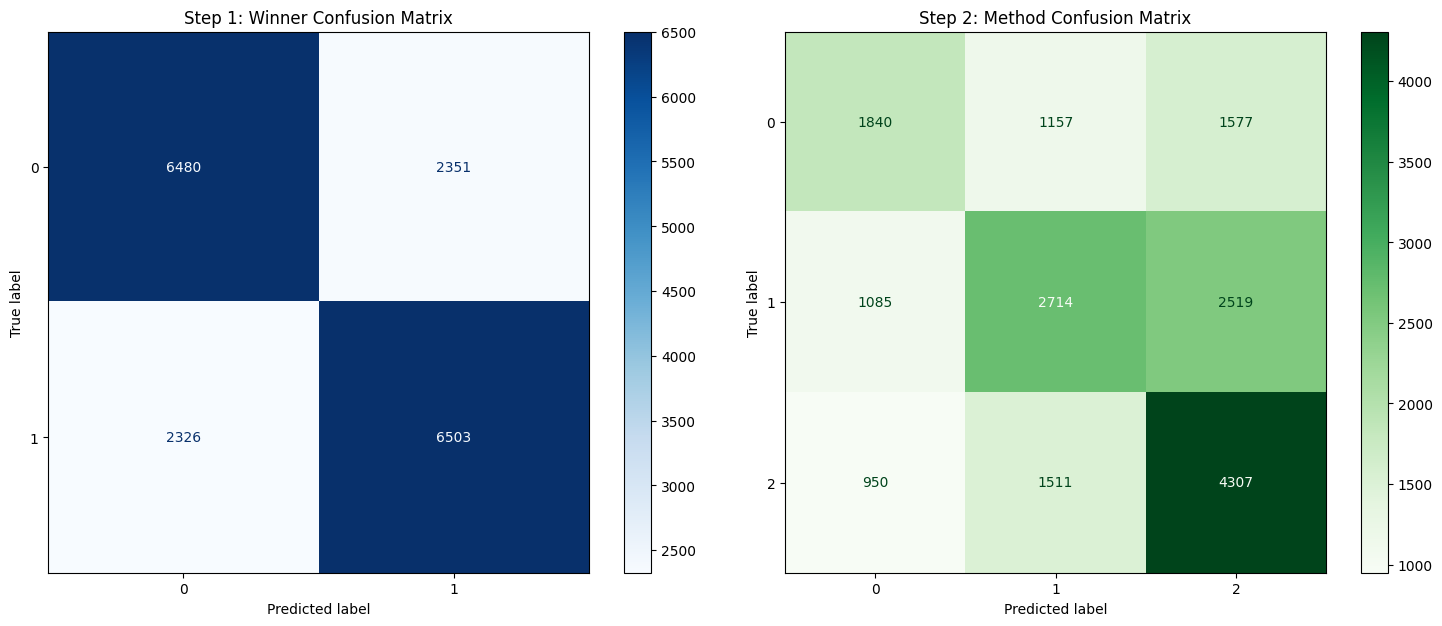

In [ ]:
# Set up the plotting area
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# --- Matrix 1: Winner Model (Step 1) ---
cm1 = confusion_matrix(df_test['result'], df_test['win_pred'])
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1)
disp1.plot(ax=ax[0], cmap='Blues', values_format='d')
ax[0].set_title('Step 1: Winner Confusion Matrix')

# --- Matrix 2: Method Model (Step 2) ---
cm2 = confusion_matrix(df_test['method'], vc2.predict(df_test[X2_cols]))
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2)
disp2.plot(ax=ax[1], cmap='Greens', values_format='d')
ax[1].set_title('Step 2: Method Confusion Matrix')

plt.tight_layout()
plt.show()

In [ ]:
less_than_3=len(df_step1_errors[(df_step1_errors['total_fights_1']<3)| (df_step1_errors['total_fights_2']<3)])
less_than_3/len(df_step1_errors)

0.4894162924951892

In [ ]:
# Filter for rows where BOTH fighters have at least 3 fights
df_experienced = df_test[(df_test['total_fights_1'] >= 3) & (df_test['total_fights_2'] >= 3)].copy()

print(f"Total fights in original test set: {len(df_test)}")
print(f"Total fights with experienced fighters (3+ fights): {len(df_experienced)}")
print(f"Fights excluded: {len(df_test) - len(df_experienced)}")

Total fights in original test set: 17660
Total fights with experienced fighters (3+ fights): 7456
Fights excluded: 10204


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

# Step 1: Winner Performance
y1_true_exp = df_experienced['result']
y1_pred_exp = df_experienced['win_pred']

# Step 2: Method Performance
y2_true_exp = df_experienced['method']
y2_pred_exp = vc2.predict(df_experienced[X2_cols])

print("\n" + "="*40)
print("🏆 PERFORMANCE ON EXPERIENCED FIGHTERS (3+ Fights)")
print("-" * 40)
print(f"Winner Accuracy: {accuracy_score(y1_true_exp, y1_pred_exp):.4f}")
print(f"Method F1 (Macro): {f1_score(y2_true_exp, y2_pred_exp, average='macro'):.4f}")
print("="*40)


🏆 PERFORMANCE ON EXPERIENCED FIGHTERS (3+ Fights)
----------------------------------------
Winner Accuracy: 0.6797
Method F1 (Macro): 0.4969


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt

# --- 1. CROSS VALIDATION ---
# Using f1_weighted to account for class imbalance (especially in 'method')
cv_scores_w = cross_val_score(vc1, df_train[X1_cols], df_train['result'], cv=5, scoring='f1')
cv_scores_m = cross_val_score(vc2, df_train[X2_cols], df_train['method'], cv=5, scoring='f1_macro')

print("--- Cross Validation Results (F1-Weighted) ---")
print(f"Winner Model CV Mean: {cv_scores_w.mean():.4f} (+/- {cv_scores_w.std() * 2:.4f})")
print(f"Method Model CV Mean: {cv_scores_m.mean():.4f} (+/- {cv_scores_m.std() * 2:.4f})")
print("-" * 45)

--- Cross Validation Results (F1-Weighted) ---
Winner Model CV Mean: 0.7354 (+/- 0.0065)
Method Model CV Mean: 0.4850 (+/- 0.0043)
---------------------------------------------


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

# 1. הפקת חיזויים עבור סט הבדיקה (Test Set)
y1_true = df_test['result']
y1_pred = df_test['win_pred'] # כבר קיים אצלך ב-df_test משלב 5

# 2. יצירת מטריצת בלבול
cm1 = confusion_matrix(y1_true, y1_pred)

# 3. חישוב אחוזי דיוק (Recall) לכל מחלקה
# חלוקת כל אלכסון בסכום השורה שלו
per_class_acc = cm1.diagonal() / cm1.sum(axis=1)

print("\n" + "="*40)
print("דיוק המודל הראשון לכל אפשרות (Winner Accuracy):")
print("-" * 40)

# נניח ש-0 זה לוחם 1 ו-1 זה לוחם 2
for i, acc in enumerate(per_class_acc):
    print(f"🔹 אפשרות {i} (Result {i}): {acc:.2%}")

print("="*40)

# בונוס: בדיקה אם המודל מוטה (Bias)
total_preds = len(y1_pred)
dist_preds = np.bincount(y1_pred.astype(int)) / total_preds
print(f"התפלגות החיזויים של המודל: {dist_preds}")


דיוק המודל הראשון לכל אפשרות (Winner Accuracy):
----------------------------------------
🔹 אפשרות 0 (Result 0): 73.38%
🔹 אפשרות 1 (Result 1): 73.66%
התפלגות החיזויים של המודל: [0.498641 0.501359]


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

# 1. הפקת חיזויים עבור סט הבדיקה של שלב 2
y2_true = df_test['method']
y2_pred = vc2.predict(df_test[X2_cols])

# 2. יצירת מטריצת בלבול
cm2 = confusion_matrix(y2_true, y2_pred)

# 3. חילוץ שמות המחלקות (KO, Decision, Submission וכו')
# vc2.classes_ מכיל את השמות המקוריים אם הם עברו LabelEncoding לפני
method_names = vc2.classes_

# 4. חישוב אחוזי דיוק (Recall) לכל מחלקה
# חלוקת האלכסון (הצלחות) בסכום השורה (סך המקרים האמיתיים)
per_method_acc = cm2.diagonal() / cm2.sum(axis=1)

print("\n" + "="*45)
print("🥋 דיוק המודל השני לכל שיטת ניצחון (Method Accuracy):")
print("-" * 45)

for i, acc in enumerate(per_method_acc):
    # טיפול במקרה של חלוקה באפס (אם מחלקה מסוימת לא הופיעה ב-Test)
    accuracy = acc if not np.isnan(acc) else 0.0
    print(f"🔹 {method_names[i]:15} : {accuracy:.2%}")

print("="*45)


🥋 דיוק המודל השני לכל שיטת ניצחון (Method Accuracy):
---------------------------------------------
🔹               1 : 40.23%
🔹               2 : 42.96%
🔹               3 : 63.64%


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score

# --- 1. פונקציה ליצירת נתונים עם רעש ---
def create_noisy_test_set(df_source, features_list, noise_level=0.05):
    """
    יוצר העתק של הנתונים עם רעש גאוסיאני לפיצ'רים מספריים
    """
    df_noisy = df_source.copy()

    for col in features_list:
        if df_noisy[col].dtype in [np.float64, np.int64]:
            # חישוב סטיית התקן והזרקת רעש יחסי
            std = df_noisy[col].std()
            if std > 0:
                noise = np.random.normal(0, noise_level * std, size=len(df_noisy))
                df_noisy[col] = df_noisy[col] + noise

    return df_noisy

# --- 2. יצירת סט הבדיקה המורעש ---
# נשתמש ב-df_test המקורי שלך וניצור ממנו 1000 דוגמאות מורעשות
df_noisy_test = df_test.sample(n=1000, replace=True, random_state=42).copy()
df_noisy_test = create_noisy_test_set(df_noisy_test, X1_cols, noise_level=0.05)

# --- 3. הרצה בשלב 1 (Winner) ---
# שימוש ב-vc1 שכבר אומן
y1_noise_preds = vc1.predict(df_noisy_test[X1_cols])
y1_noise_probs = vc1.predict_proba(df_noisy_test[X1_cols])[:, 1]

# עדכון ה-df עם המטא-פיצ'רים החדשים שנוצרו מהרעש
df_noisy_test['win_prob'] = y1_noise_probs
df_noisy_test['win_pred'] = y1_noise_preds

# --- 4. הרצה בשלב 2 (Method) ---
# שימוש ב-vc2 שכבר אומן
y2_noise_preds = vc2.predict(df_noisy_test[X2_cols])

# --- 5. הדפסת תוצאות השוואתיות ---
print("🧪 --- בדיקת עמידות: הזרקת רעש (1000 קרבות) ---")
print(f"Winner Model Accuracy (With Noise): {accuracy_score(df_noisy_test['result'], y1_noise_preds):.4f}")
print(f"Method Model f1 (macro) (With Noise): {f1_score(df_noisy_test['method'], y2_noise_preds, average='macro'):.4f}")

# השוואה לדיוק המקורי (ששמרת קודם בסקריפט)
print(f"\nTarget Accuracy (No Noise): Winner: {test_acc:.4f} | Method: (Check your previous output)")

🧪 --- בדיקת עמידות: הזרקת רעש (1000 קרבות) ---
Winner Model Accuracy (With Noise): 0.7140
Method Model f1 (macro) (With Noise): 0.4808

Target Accuracy (No Noise): Winner: 0.7352 | Method: (Check your previous output)


In [ ]:
#בדיקה על קרבות חדשים מנובמבר 2025 ל פברואר 2026 בעלי איכות טובה
import pandas as pd

# 1. ה-ID שחולץ מהקישור החדש ששלחת
FILE_ID = '1MBWPQq7ISWbGZLhF_88xLGt-efkHbdLp'

# 2. יצירת הכתובת להורדה ישירה (מבנה קבוע שמאפשר ל-pandas לקרוא את הקובץ)
direct_url = f'https://drive.google.com/uc?export=download&id={FILE_ID}'
test_set = pd.read_csv(direct_url)

In [ ]:
test_set.drop('date',axis=1,inplace=True)

In [ ]:
mapping = {0: 2, 2: 3}

# Apply the change to the 'method' column
test_set['method'] = test_set['method'].replace(mapping)

In [ ]:
test_set['result']=test_set['result']-1


In [ ]:
df_new=test_set.copy()

In [ ]:
# Apply the same feature engineering used during training
df_new_processed = add_mma_features(df_new)

#


In [ ]:
# --- STEP 1: WINNER PREDICTIONS ---
# Predict probabilities and classes
df_new_processed['win_prob'] = vc1.predict_proba(df_new_processed[X1_cols])[:, 1]
df_new_processed['win_pred'] = vc1.predict(df_new_processed[X1_cols])

# --- STEP 2: METHOD PREDICTIONS ---
# Now that we have 'win_prob', we can run the Method model
# Note: X2_cols must contain exactly what the model was trained on (X1_cols + 'win_prob')
y2_new_preds = vc2.predict(df_new_processed[X2_cols])
df_new_processed['method_pred'] = y2_new_preds

In [ ]:
from sklearn.metrics import accuracy_score, f1_score


new_winner_acc = accuracy_score(df_new_processed['result'], df_new_processed['win_pred'])
new_method_f1 = f1_score(df_new_processed['method'], df_new_processed['method_pred'], average='macro')

print(f"Winner Accuracy: {new_winner_acc:.4f}")
print(f"Method F1 (Macro): {new_method_f1:.4f}")




Winner Accuracy: 0.6649
Method F1 (Macro): 0.5393
